# Systematics 2D Dev

Load the test FLT, extract the ROI, and plot full frame and ROI with cbrt stretch. Includes a row fit that respects DQ flags and ROI limits.

In [2]:
from pathlib import Path

import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt

# Use interactive backend in Jupyter
%matplotlib widget

import sys
sys.path.append('..')
from models import airglow_broadened_boxcar_row

In [3]:
# Configuration
flt_path = Path("../test-data/of9b05010_flt.fits")
roi_x0, roi_x1 = 380, 420
roi_y0, roi_y1 = 185, 205

# DQ flags to mask (bitwise)
dq_flags = [1, 2, 4, 16, 32, 256, 512, 8192]
dq_mask_value = int(np.sum(dq_flags))

In [4]:
# Load FLT and extract ROI
with fits.open(flt_path) as hdul:
    sci = hdul["SCI"].data.astype(float)
    dq = hdul["DQ"].data.astype(int) if "DQ" in hdul else None

roi = sci[roi_y0:roi_y1, roi_x0:roi_x1]
print("Full shape:", sci.shape, "ROI shape:", roi.shape)

Full shape: (1024, 1024) ROI shape: (20, 40)


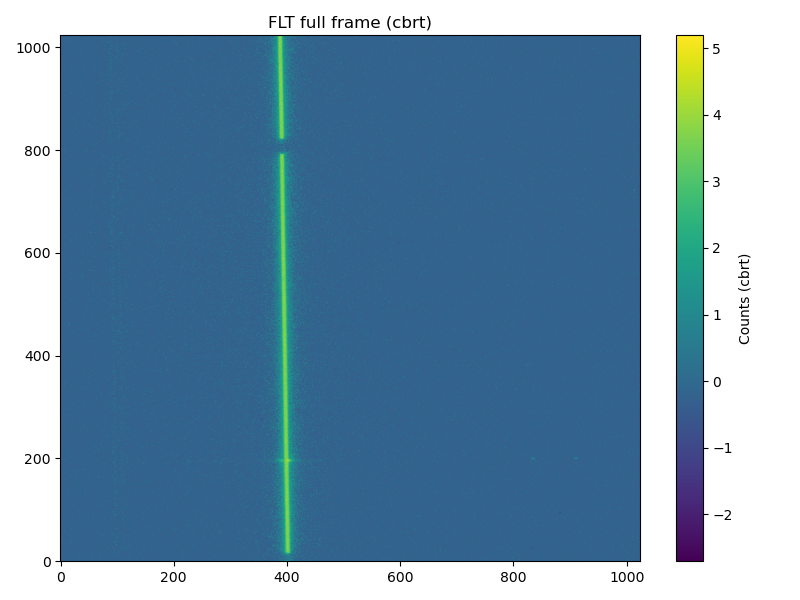

In [5]:
# Plot full frame (cbrt stretch)
full_display = np.cbrt(sci)

plt.figure(figsize=(8, 6))
plt.imshow(full_display, origin="lower", aspect="auto")
plt.colorbar(label="Counts (cbrt)")
plt.title("FLT full frame (cbrt)")
plt.tight_layout()

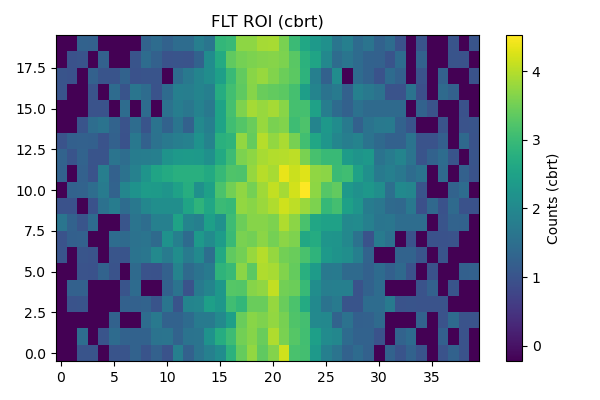

In [6]:
# Plot ROI (cbrt stretch)
roi_display = np.cbrt(roi)

plt.figure(figsize=(6, 4))
plt.imshow(roi_display, origin="lower", aspect="auto")
plt.colorbar(label="Counts (cbrt)")
plt.title("FLT ROI (cbrt)")
plt.tight_layout()

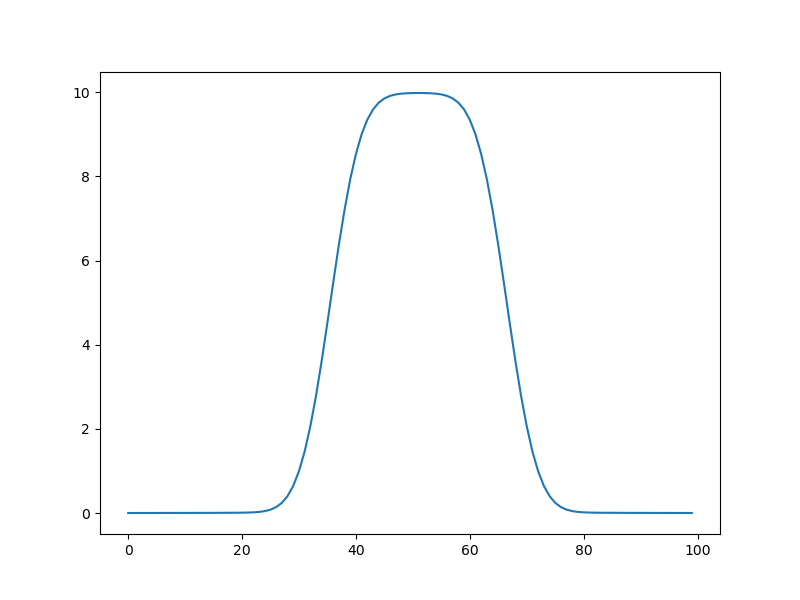

In [7]:
# Define parameters for the airglow model

xgrid = np.arange(0, 100)

# Define the airglow model parameters
centroid = 50
width = 30
fwhm_g = 10
fwhm_l = 0.1
amplitude = 10

# Compute the airglow model
model = airglow_broadened_boxcar_row(xgrid, centroid, width, amplitude, fwhm_g, fwhm_l)

# Plot the model
plt.figure(figsize=(8, 6))
plt.plot(xgrid, model)

Fit params: [397.           6.00000001  49.68929167   1.2057926    0.53306713]
N pixels masked: 0


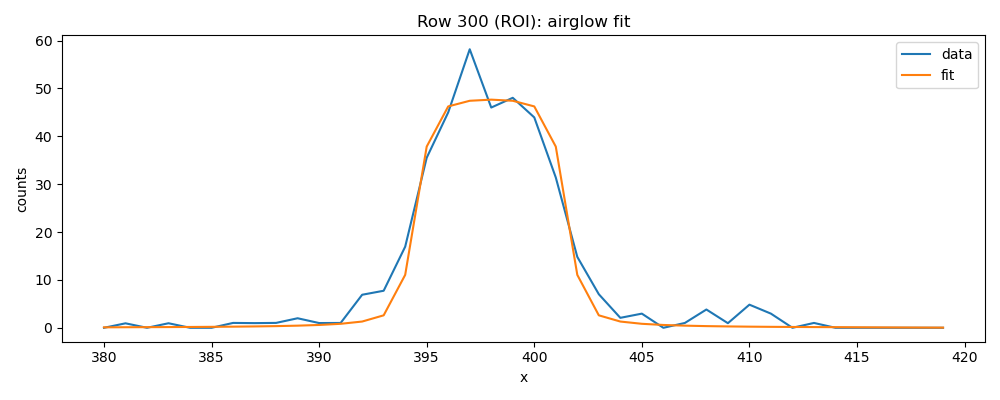

In [13]:
# Fit a selected row using the helper functions
import models

row_index = 300  # pick a row in the full frame
row = sci[row_index]
x_grid = np.arange(len(row))

# Build DQ row if available
if dq is not None:
    dq_row = dq[row_index]
else:
    dq_row = None

fit, params, keep = models.fit_airglow_row(
    row,
    x_grid,
    roi_x0,
    roi_x1,
    dq_row=dq_row,
    dq_mask_value=dq_mask_value,
    lsf_kernel=None,
    init=None,
)

x_roi = x_grid[roi_x0:roi_x1]
row_roi = row[roi_x0:roi_x1]

print("Fit params:", params)

plt.figure(figsize=(10, 4))
plt.plot(x_roi, row_roi, label="data")
plt.plot(x_roi, fit, label="fit")
plt.xlabel("x")
plt.ylabel("counts")
plt.title(f"Row {row_index} (ROI): airglow fit")
plt.legend()
plt.tight_layout()

print('N pixels masked:', np.sum(~keep))

In [ ]:
# Fit airglow model across ROI rows
import models

rows = sci[roi_y0:roi_y1]
row_indices = np.arange(roi_y0, roi_y1)
if dq is not None:
    dq_rows = dq[roi_y0:roi_y1]
else:
    dq_rows = None

x_grid = np.arange(sci.shape[1])

fit_results = models.fit_airglow_rows(
    rows,
    x_grid,
    roi_x0,
    roi_x1,
    row_indices=row_indices,
    dq_rows=dq_rows,
    dq_mask_value=dq_mask_value,
    lsf_kernel=None,
    init=None,
)

roi_fit = fit_results["fits"]
print("Fitted rows:", roi_fit.shape)

In [ ]:
# Plot original ROI, fit image, and difference
roi_data = sci[roi_y0:roi_y1, roi_x0:roi_x1]
residual = roi_data - roi_fit

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for ax, img, title in zip(
    axes,
    [roi_data, roi_fit, residual],
    ["ROI data", "Airglow fit", "Residual"],
):
    disp = np.cbrt(img)
    vmin = np.nanpercentile(disp, 5)
    vmax = np.nanpercentile(disp, 95)
    ax.imshow(disp, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title)

plt.tight_layout()

In [ ]:
# Plot fit parameters vs row index
params = fit_results["params"]
labels = ["centroid", "width", "amplitude", "fwhm_g", "fwhm_l"]

fig, axes = plt.subplots(len(labels), 1, figsize=(8, 10), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(row_indices, params[:, i], marker="o", ms=2)
    ax.set_ylabel(label)
axes[-1].set_xlabel("row index")
plt.tight_layout()